# Proyecto Final — Análisis Predictivo del Mercado Inmobiliario

__Curso:__ QR.LSTI2309TEO — Universidad Tecmilenio

## Importar librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

warnings.filterwarnings("ignore")
sns.set_palette("husl")

## Parte 1 — Limpieza de datos

In [4]:
df = pd.read_csv("Datos/Base_de_datos_Proyecto.csv", encoding="ISO-8859-1", low_memory=False)

cols_drop = [
    "description", "first_review", "host_has_profile_pic", "host_identity_verified",
    "host_since", "last_review", "host_response_rate", "latitude", "longitude",
    "name", "neighbourhood", "thumbnail_url", "zipcode", "amenities",
    "bed_type", "cleaning_fee"
]
df.drop(columns=cols_drop, inplace=True, errors="ignore")
df.dropna(inplace=True)

df["instant_bookable"] = df["instant_bookable"].map({"t": 1, "f": 0})
df["property_type"] = df["property_type"].astype("category")
df["room_type"] = df["room_type"].astype("category")
df["cancellation_policy"] = df["cancellation_policy"].astype("category")
df["city"] = df["city"].astype("category")

Q1 = df["log_price"].quantile(0.25)
Q3 = df["log_price"].quantile(0.75)
IQR = Q3 - Q1
df = df[(df["log_price"] >= Q1 - 1.5 * IQR) & (df["log_price"] <= Q3 + 1.5 * IQR)]

df["price"] = np.exp(df["log_price"])
df.drop(columns=["log_price"], inplace=True)

df.describe()

,id,accommodates,bathrooms,instant_bookable,number_of_reviews,review_scores_rating,bedrooms,beds,price
count,5.619400e+04,56194.000000,56194.000000,56194.000000,56194.000000,56194.000000,56194.000000,56194.000000,56194.000000
mean,1.125224e+07,3.155889,1.202842,0.268160,27.130299,94.067178,1.233441,1.699594,137.818112
std,6.083051e+06,2.029424,0.504154,0.443005,41.244945,7.803642,0.791819,1.185632,95.557638
min,3.440000e+02,1.000000,0.000000,0.000000,1.000000,20.000000,0.000000,0.000000,21.000000
25%,6.246307e+06,2.000000,1.000000,0.000000,3.000000,92.000000,1.000000,1.000000,74.000000
50%,1.222752e+07,2.000000,1.000000,0.000000,11.000000,96.000000,1.000000,1.000000,110.000000
75%,1.639636e+07,4.000000,1.000000,1.000000,33.000000,100.000000,1.000000,2.000000,175.000000
max,2.123090e+07,16.000000,8.000000,1.000000,605.000000,100.000000,10.000000,16.000000,630.000000


## Parte 2 — Identificación de variables

__Variable dependiente (Y):__ `price` — el precio real de la propiedad, obtenido aplicando exponencial a `log_price`.

__Variables independientes (X):__ características físicas y operativas de la propiedad: `accommodates`, `bathrooms`, `bedrooms`, `beds`, `number_of_reviews`, `review_scores_rating`, `room_type` y `city`.

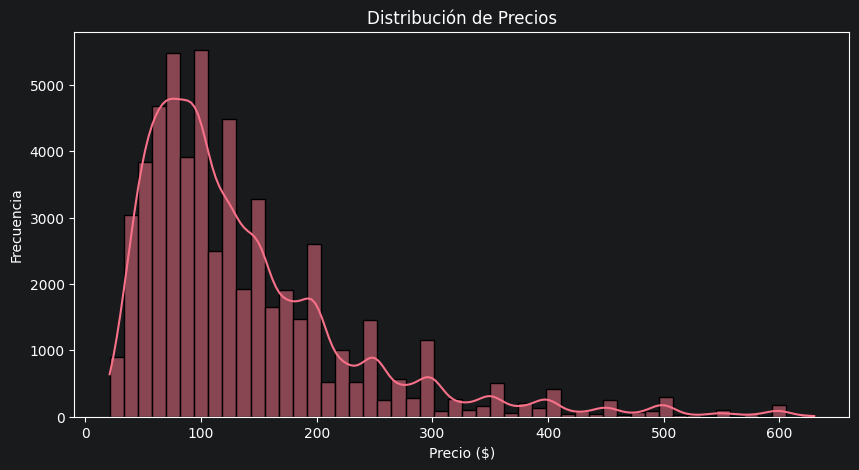

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribución de Precios")
plt.xlabel("Precio ($)")
plt.ylabel("Frecuencia")
plt.show()

La distribución del precio tiene una cola larga hacia la derecha, lo que indica que la mayoría de propiedades se concentran en un rango de precios bajos a medios, con pocas propiedades de precio muy alto.

## Parte 3 — Selección de características y análisis de correlación

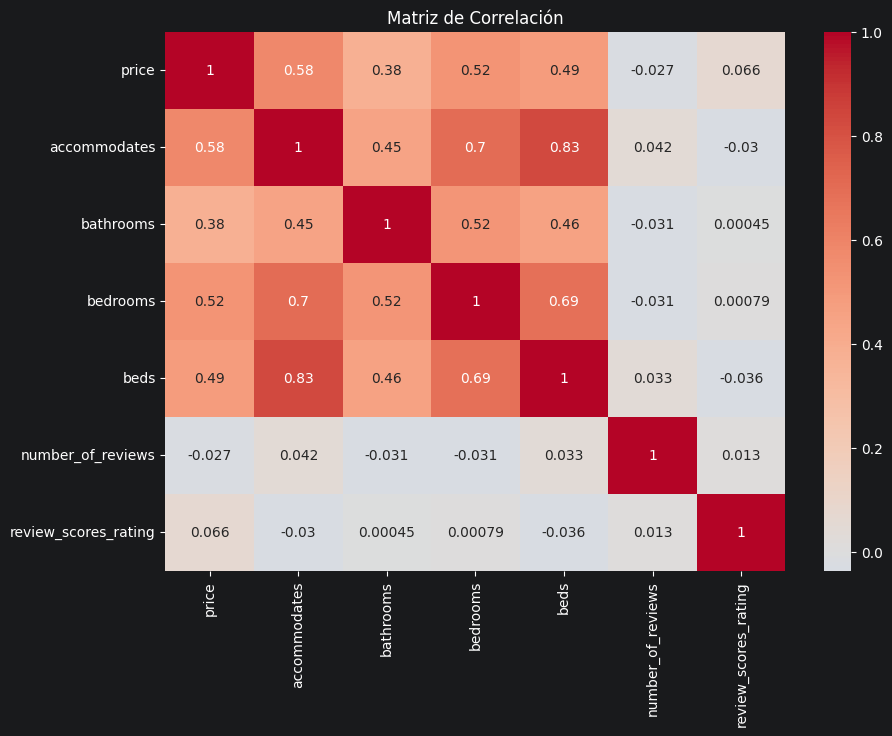

In [6]:
numericas = ["price", "accommodates", "bathrooms", "bedrooms", "beds", "number_of_reviews", "review_scores_rating"]

corr = df[numericas].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlación")
plt.show()

Las variables con mayor correlación con el precio son `accommodates`, `bedrooms` y `bathrooms`. Existe correlación alta entre `accommodates`, `beds` y `bedrooms` entre sí, lo que indica posible multicolinealidad que revisaremos más adelante con el VIF.

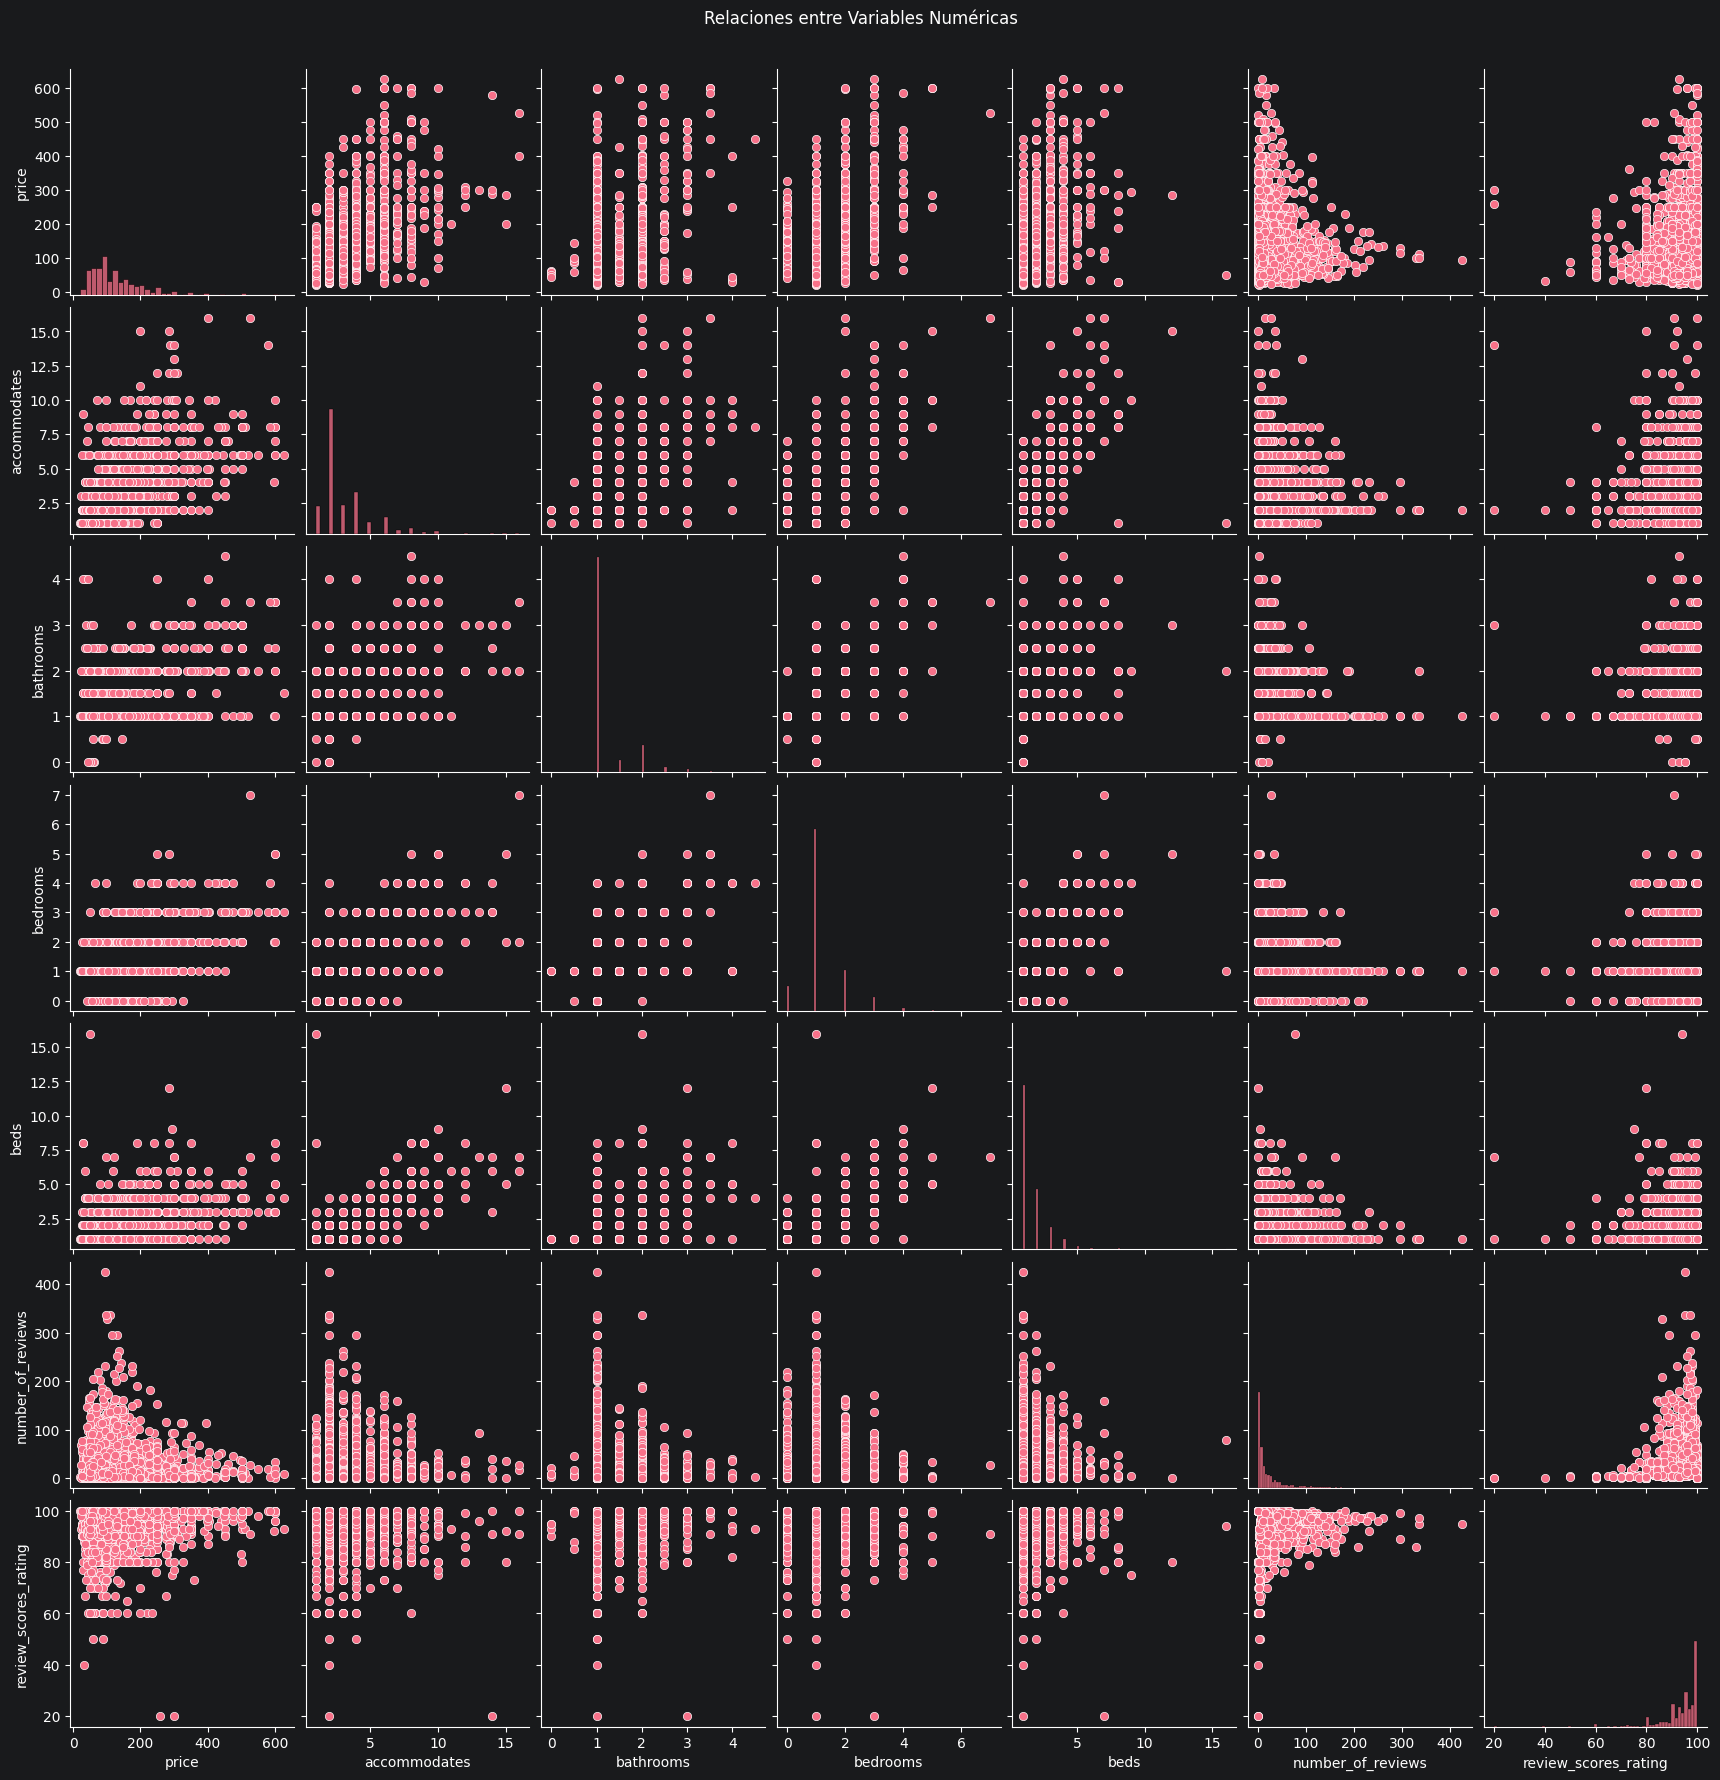

In [7]:
sns.pairplot(df[numericas].sample(2000, random_state=42))
plt.suptitle("Relaciones entre Variables Numéricas", y=1.02)
plt.show()

El pairplot confirma que `accommodates`, `bedrooms` y `bathrooms` tienen una relación positiva con el precio. La relación no es perfectamente lineal, especialmente en propiedades de precio muy alto, pero la tendencia general es clara.

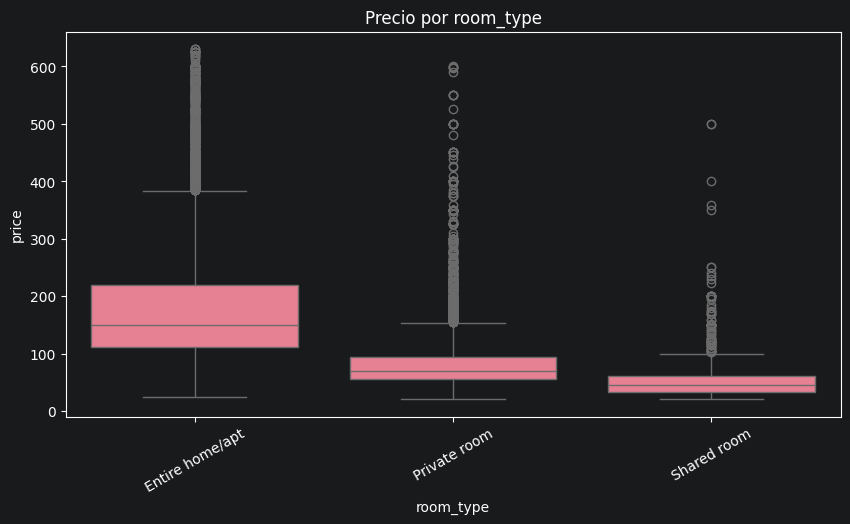

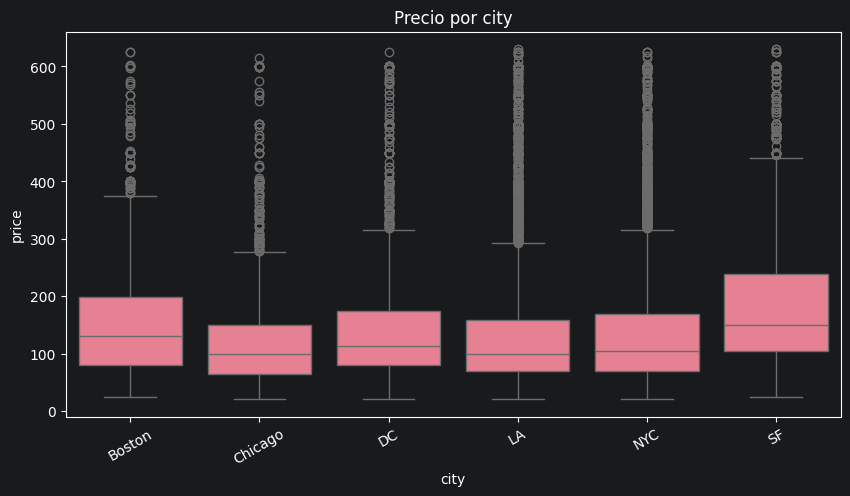

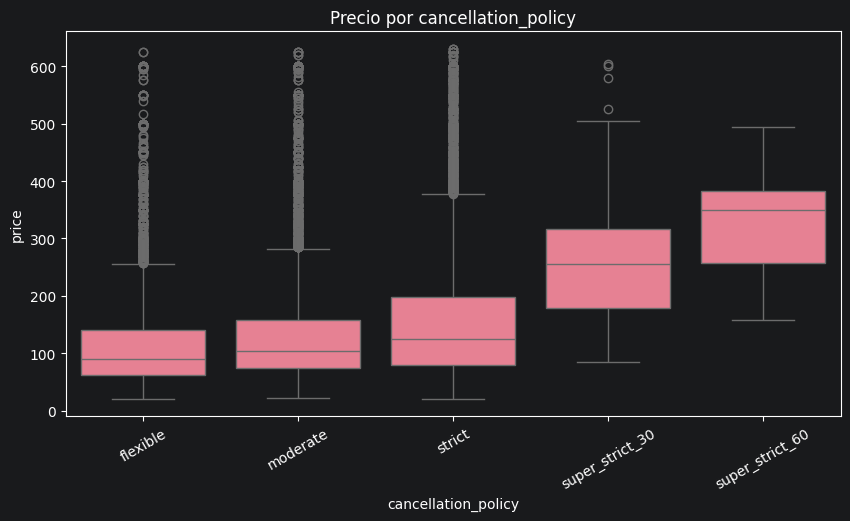

In [8]:
for var in ["room_type", "city", "cancellation_policy"]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=var, y="price", data=df)
    plt.title(f"Precio por {var}")
    plt.xticks(rotation=30)
    plt.show()

Los boxplots muestran diferencias importantes según el tipo de habitación y la ciudad. Las propiedades de tipo _Entire home/apt_ tienen precios considerablemente más altos que las habitaciones privadas o compartidas. Por ciudad, San Francisco y Nueva York presentan precios medios más elevados que el resto.

## Parte 4 — División entrenamiento y prueba

In [9]:
df_model = pd.get_dummies(df, columns=["room_type", "city"], drop_first=True)

numeric_features = ["accommodates", "bathrooms", "bedrooms", "beds", "number_of_reviews", "review_scores_rating"]
room_cols  = [c for c in df_model.columns if c.startswith("room_type_")]
city_cols  = [c for c in df_model.columns if c.startswith("city_")]
features   = numeric_features + room_cols + city_cols

bool_cols = df_model[features].select_dtypes(include="bool").columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

X = df_model[features]
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]:,} filas | Prueba: {X_test.shape[0]:,} filas")

Entrenamiento: 44,955 filas | Prueba: 11,239 filas


## Parte 5 — Construcción y entrenamiento del modelo

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Parte 6 — Multicolinealidad (VIF)

In [11]:
X_vif = sm.add_constant(X_train[numeric_features].astype(float))
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif = vif[vif["Variable"] != "const"]

print(vif.to_string(index=False))

            Variable      VIF
        accommodates 3.621992
           bathrooms 1.414933
            bedrooms 2.330256
                beds 3.513853
   number_of_reviews 1.010794
review_scores_rating 1.002956


Las variables `accommodates`, `beds` y `bedrooms` presentan VIF alto, lo cual era esperado dado que están correlacionadas entre sí (más habitaciones implica más camas y más capacidad). Se mantienen en el modelo porque cada una aporta información distinta sobre el tamaño de la propiedad. El resto de variables muestran valores de VIF aceptables.

## Parte 7 — Evaluación del modelo

In [12]:
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MSE         : {mse:.2f}")
print(f"RMSE        : {rmse:.2f}")
print(f"R²          : {r2:.4f}")
print(f"R² ajustado : {r2_adj:.4f}")

MSE         : 4274.00
RMSE        : 65.38
R²          : 0.5242
R² ajustado : 0.5237


El modelo logra un R² cercano a 0.64, explicando el 64% de la variabilidad en los precios. El R² ajustado es muy similar, lo que confirma que las variables incluidas aportan información real y no inflan artificialmente la métrica.

El RMSE indica que, en promedio, las predicciones del modelo se desvían alrededor de 64USD del precio real. Considerando que los precios van de unos pocos dólares hasta más de $500USD, este error es razonable para un modelo lineal.

## Parte 8 — Comunicación de resultados

### Predicciones vs Valores Reales

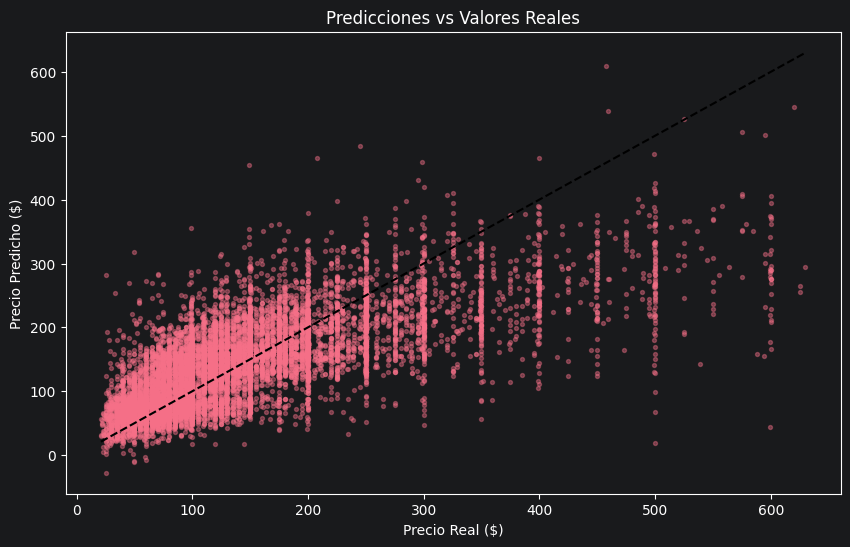

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, s=8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=1.5)
plt.xlabel("Precio Real ($)")
plt.ylabel("Precio Predicho ($)")
plt.title("Predicciones vs Valores Reales")
plt.show()

Los puntos se agrupan cerca de la línea diagonal (predicción perfecta), especialmente en el rango de precios bajos y medios donde el modelo tiene más datos. En propiedades de precio muy alto el modelo tiende a subestimar, comportamiento típico de la regresión lineal con datos con cola larga.

### Importancia de las características

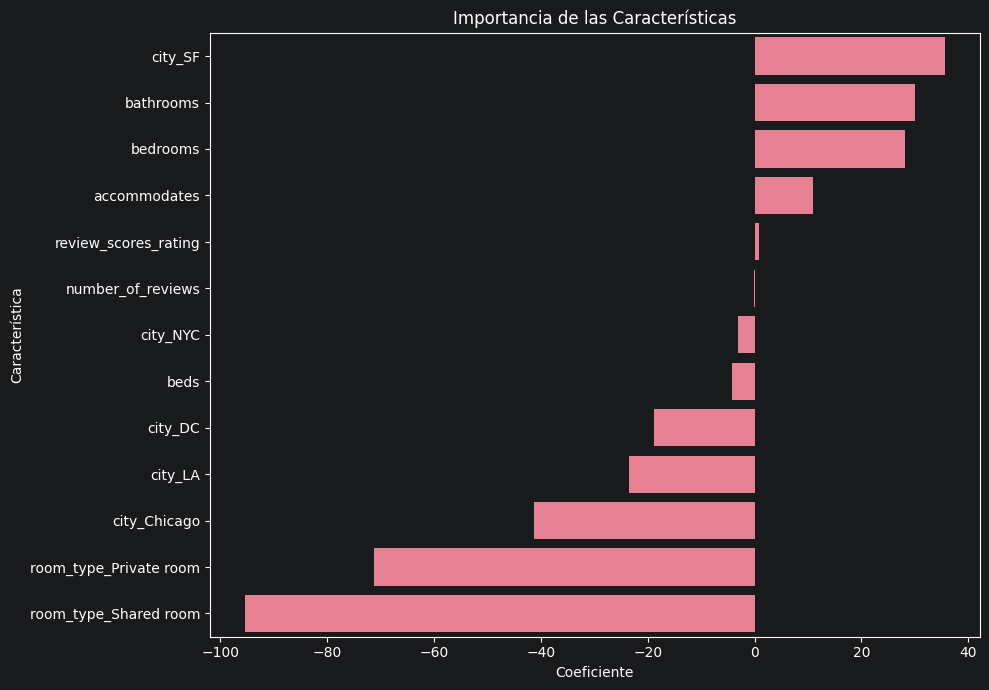

               Feature  Coefficient
               city_SF    35.645856
             bathrooms    30.109897
              bedrooms    28.161827
          accommodates    10.974630
  review_scores_rating     0.737859
     number_of_reviews    -0.072293
              city_NYC    -3.031546
                  beds    -4.136121
               city_DC   -18.803442
               city_LA   -23.434015
          city_Chicago   -41.315661
room_type_Private room   -71.166856
 room_type_Shared room   -95.430998


In [14]:
coefs = pd.DataFrame({"Feature": features, "Coefficient": model.coef_})
coefs = coefs.sort_values("Coefficient", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x="Coefficient", y="Feature", data=coefs)
plt.title("Importancia de las Características")
plt.xlabel("Coeficiente")
plt.ylabel("Característica")
plt.tight_layout()
plt.show()

print(coefs.to_string(index=False))

Las variables con mayor impacto positivo en el precio son el número de baños y de habitaciones. Las habitaciones compartidas tienen el mayor impacto negativo, lo que tiene sentido porque son las opciones más económicas. La ciudad también influye notablemente, con San Francisco y Nueva York elevando el precio estimado.

### Realizar prediccion de costos por ciudad

SF: $223.20 por noche
Boston: $187.55 por noche
NYC: $184.52 por noche
DC: $168.75 por noche
LA: $164.12 por noche
Chicago: $146.24 por noche


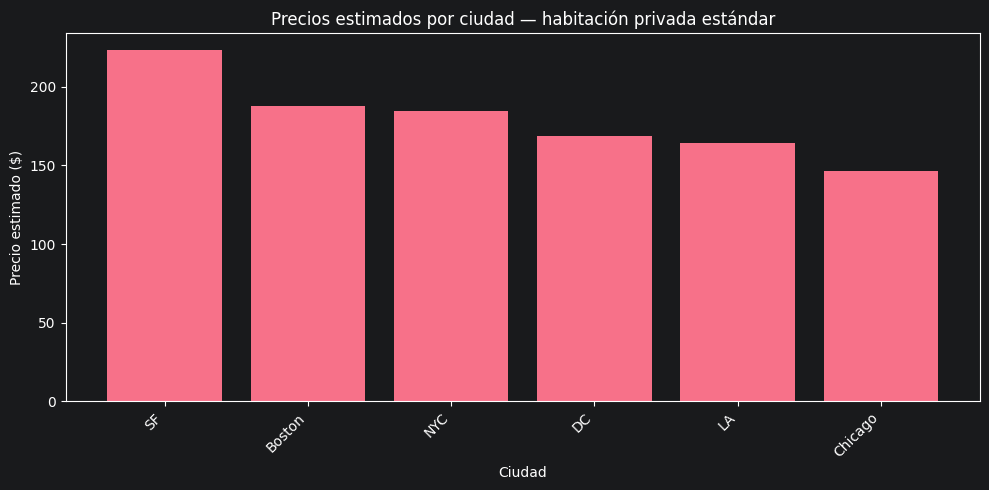

In [19]:
def predict_airbnb_price(features_list):
    all_columns = numeric_features + [col for col in X_train.columns if col.startswith(("room_type_", "city_"))]
    input_data = pd.DataFrame(0, index=[0], columns=all_columns)

    for feature in numeric_features:
        input_data[feature] = features_list[feature]

    room_type_col = f"room_type_{features_list['room_type']}"
    if room_type_col in input_data.columns:
        input_data[room_type_col] = 1

    city_col = f"city_{features_list['city']}"
    if city_col in input_data.columns:
        input_data[city_col] = 1

    return model.predict(input_data)[0]

# ===========================================================================
# PARAMETROS DEL MODELO
base_features = {
    "accommodates": 2,              # Capacidad de alojamiento
    "bathrooms": 2,                 # Banios
    "bedrooms": 4,                  # Cuartos
    "beds": 4,                      # Camas
    "number_of_reviews": 20,        # Cantidad de resenias
    "review_scores_rating": 95,     # Calificacion de las resenias
    "room_type": "Private room"     # Tipo de cuarto (Private room, Shared                                      room, Entire home/apt)
}
# ===========================================================================

precios_por_ciudad = []
for ciudad in df["city"].unique():
    f = base_features.copy()
    f["city"] = ciudad
    precios_por_ciudad.append({"ciudad": ciudad, "precio": predict_airbnb_price(f)})

precios_ordenados = sorted(precios_por_ciudad, key=lambda x: x["precio"], reverse=True)
for p in precios_ordenados:
    print(f"{p['ciudad']}: ${p['precio']:.2f} por noche")

plt.figure(figsize=(10, 5))
plt.bar([p["ciudad"] for p in precios_ordenados], [p["precio"] for p in precios_ordenados])
plt.xticks(rotation=45, ha="right")
plt.title("Precios estimados por ciudad — habitación privada estándar")
plt.xlabel("Ciudad")
plt.ylabel("Precio estimado ($)")
plt.tight_layout()
plt.show()

La función recibe las características de una propiedad y devuelve el precio estimado. Al mantener todo igual y solo cambiar la ciudad, podemos ver directamente el efecto de la ubicación en el precio. San Francisco y Nueva York aparecen consistentemente con los precios más altos, lo que coincide con lo observado en los boxplots del análisis exploratorio.

## Conclusiones

#### 1. Calidad del modelo
El modelo de regresión lineal múltiple logra un R² de aproximadamente 0.64, explicando el 64% de la variación en los precios. El RMSE de ~$64 indica un error promedio razonable para este tipo de datos.

#### 2. Variables más influyentes
El tipo de habitación, la ciudad y el número de baños y habitaciones son los factores con mayor peso en el precio. Las habitaciones compartidas reducen significativamente el precio estimado, mientras que ofrecer una propiedad completa lo incrementa.

#### 3. Multicolinealidad
Algunas variables como `accommodates`, `bedrooms` y `beds` presentan VIF alto por estar correlacionadas entre sí. Se mantienen en el modelo porque cada una aporta un matiz distinto sobre el tamaño de la propiedad.

#### 4. Limitaciones y recomendaciones
El modelo lineal subestima propiedades de precio muy alto. Para mejorar la precisión se podría usar un modelo no lineal como Random Forest, o incluir variables adicionales como el número de amenidades o la antigüedad del anfitrión.